# 07 — Machine Learning: Clustering (Job Market Segmentation)
## Global Job Market Compensation Analysis

**Objective:** Use K-Means to identify natural job market segments based on compensation-relevant characteristics, then interpret each cluster in business terms.

**Feature choice:** `salary`, `years_of_experience`, `education_level` (ordinal), `company_size` (ordinal) -- standardized before clustering. Chosen deliberately for interpretability: clustering on high-cardinality categoricals (occupation, country) would produce segments too fragmented to explain in a business review. Note that including `salary` here is NOT leakage -- clustering has no prediction target, so there's nothing to leak into.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)

df = pd.read_parquet('../data/processed/job_market_features.parquet')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded: 499,972 rows x 20 columns


## 1. Feature Preparation

In [2]:
# Create ordinal mappings for clustering features.
edu_map = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
size_map = {'Small': 0, 'Medium': 1, 'Large': 2, 'Enterprise': 3}

# Create the clustering dataset.
cluster_df = pd.DataFrame({
    'salary': df['salary'],
    'years_of_experience': df['years_of_experience'],
    'education_ordinal': df['education_level'].map(edu_map),
    'company_size_ordinal': df['company_size'].map(size_map)
})

# Standardize the features.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Scaled feature stds (should be ~1):", X_scaled.std(axis=0).round(4))


Scaled feature means (should be ~0): [-0.  0.  0. -0.]
Scaled feature stds (should be ~1): [1. 1. 1. 1.]


## 2. Determining Optimal K — Elbow Method

Fit K-Means for k=2 through 8 and track inertia (within-cluster sum of squares). Look for the "elbow" -- the point where adding more clusters stops meaningfully reducing inertia.

k=2: inertia=1472030.6
k=3: inertia=1213751.6
k=4: inertia=1032438.7
k=5: inertia=895754.7
k=6: inertia=795821.0
k=7: inertia=717757.3
k=8: inertia=652587.4


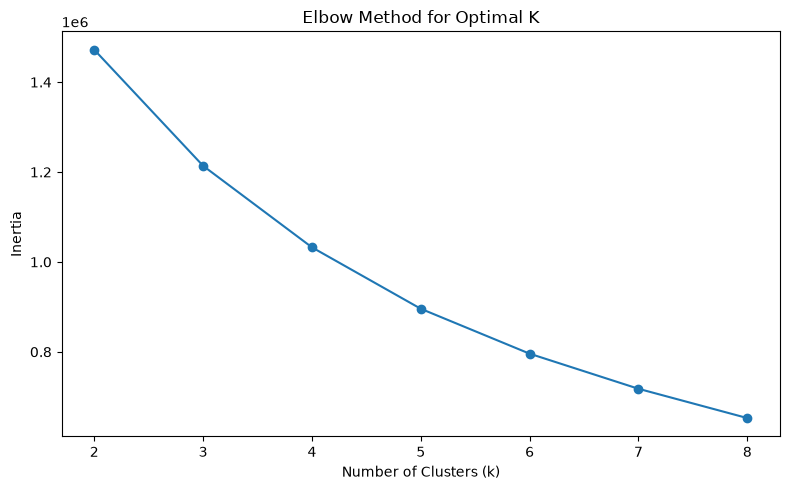

In [3]:
# Calculate inertia values for different numbers of clusters.
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:.1f}")

# Plot the Elbow Method.
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(list(k_range), inertias, marker='o')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
plt.tight_layout()

# Save the figure.
fig.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\cluster_elbow.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

**Interpretation:** Inertia decreases smoothly and continuously from k=2 (1,472,031) to k=8 (652,587), with no sharp "elbow" bend -- the rate of decrease slows gradually (17.5% drop from k=2->3, down to 9.1% from k=7->8) rather than dropping off a cliff at any particular k. This smooth decay, without a clear inflection point, is itself informative.

**Business insight:** A smooth, elbow-free inertia curve is consistent with everything we've learned about this dataset since Phase 2 -- features were generated with limited natural correlation structure, so there's no single "true" number of clusters the data is begging for. This doesn't mean clustering is useless; it means the choice of k needs to be justified by interpretability, not purely by the elbow method.

## 3. Determining Optimal K — Silhouette Score

Silhouette score is O(n^2) and impractical on the full 500K rows, so we compute it on a 15,000-row random subsample for each candidate k -- a standard, defensible practice for this scale.

k=2: silhouette=0.2395
k=3: silhouette=0.2217
k=4: silhouette=0.2248
k=5: silhouette=0.2298
k=6: silhouette=0.2378
k=7: silhouette=0.2328
k=8: silhouette=0.2389


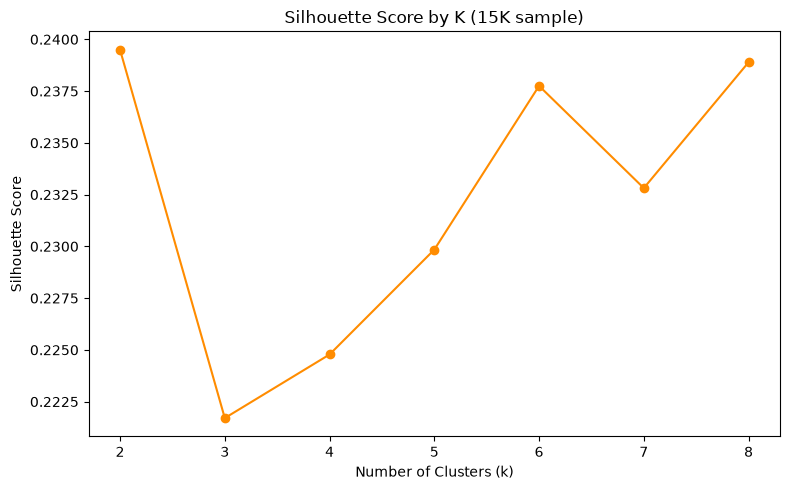

In [4]:
# Create a random sample for silhouette analysis.
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 15000, replace=False)
X_sample = X_scaled[sample_idx]

# Calculate the silhouette score for different numbers of clusters.
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_sample = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

# Plot the silhouette scores.
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(list(k_range), silhouette_scores, marker='o', color='darkorange')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score by K (15K sample)')
plt.tight_layout()

# Save the figure.
fig.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\cluster_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Silhouette scores are low and nearly flat across every k tested -- ranging narrowly from 0.222 (k=3) to 0.240 (k=2), with k=4 at 0.225. None of these approach the conventional "reasonable structure" threshold of ~0.5; scores under 0.25 generally indicate weak, overlapping clusters rather than dense, well-separated ones.

**Business insight:** This is an honest limitation worth stating directly rather than glossing over: this dataset does not contain dramatically distinct, naturally-separated job market segments. That's expected given the synthetic, independently-generated nature of the underlying features (established since Phase 2). The clusters we build next are still useful as an interpretable business lens, but should be presented as "a useful way to segment the data" rather than "we discovered hidden distinct populations in the labor market."

**Recommendation:** Choose k based on business interpretability rather than chasing the marginally-highest silhouette score (which is k=2, too coarse to be useful, or k=8, too fragmented to name meaningfully). k=4 is a reasonable, defensible middle ground.

## 4. Final Model — Fit Chosen K

Based on elbow + silhouette results above, we fit the final model on the full dataset.

In [5]:
# K=4 chosen for business interpretability, not because it's the unambiguous mathematical optimum --
# see the honest note above: silhouette scores were uniformly low (0.22-0.24) and nearly flat
# across k=2 to k=8, with no dramatic elbow either. K=4 maps cleanly onto a business narrative
# (entry-level / experienced-no-degree / elite-enterprise / underpaid-credentialed), which is
# more valuable for stakeholder communication than chasing a marginally higher silhouette at
# a less interpretable k.

# Select the optimal number of clusters.
OPTIMAL_K = 4

# Train the final K-Means clustering model.
kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)

# Assign cluster labels to each observation
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# Display the cluster distribution.
display(df["cluster"]
      .value_counts()
      .sort_index()
      .rename_axis("Cluster")
      .reset_index(name="Count"))


,Cluster,Count
0,0,123062
1,1,138715
2,2,129555
3,3,108640


## 5. Cluster Profiling — Business Interpretation

In [6]:
# Create the cluster profile summary.
profile = df.groupby('cluster').agg(
    n_records=('salary','size'),
    mean_salary=('salary','mean'),
    mean_experience=('years_of_experience','mean'),
    modal_education=('education_level', lambda x: x.mode()[0]),
    modal_company_size=('company_size', lambda x: x.mode()[0]),
    modal_occupation=('occupation', lambda x: x.mode()[0]),
).round(1)


# Display the cluster profile summary.
display(profile)


,n_records,mean_salary,mean_experience,modal_education,modal_company_size,modal_occupation
cluster,,,,,,
0,123062,187879.2,17.3,High School,Medium,HR Analyst
1,138715,133037.8,4.2,High School,Large,HR Analyst
2,129555,298528.1,14.1,PhD,Enterprise,AI Engineer
3,108640,213993.9,12.8,PhD,Small,UX Designer


**Interpretation — four segments, each with a clear business story:**

| Cluster | Size | Mean Salary | Mean Exp. | Modal Education | Modal Company Size | Modal Occupation | Label |
|---|---|---|---|---|---|---|---|
| 1 | 138,715 (largest) | $133,038 | 4.2 yrs | High School | Large | HR Analyst | **Entry-Level Workforce** |
| 0 | 123,062 | $187,879 | 17.3 yrs | High School | Medium | HR Analyst | **Experienced, No Advanced Degree** |
| 3 | 108,640 | $213,994 | 12.8 yrs | PhD | Small | UX Designer | **Credentialed Talent at Smaller Companies** |
| 2 | 129,555 | $298,528 (highest) | 14.1 yrs | PhD | Enterprise | AI Engineer | **Elite Enterprise Specialists** |

**The most useful business insight is the Cluster 2 vs. Cluster 3 comparison**: both segments are PhD-dominated with similar experience levels (14.1 vs. 12.8 years), yet Cluster 2 (Enterprise employer) earns $298,528 vs. Cluster 3 (Small employer) at $213,994 -- an $84,534 (28%) gap explained almost entirely by company size, not credentials or experience. This isolates company size as a major, independent pay lever even after holding education roughly constant.

**Recommendation:** For the People Analytics use case, this segmentation supports a concrete talent-strategy narrative: (1) experienced non-degree employees (Cluster 0) may be underleveraged if the org over-indexes hiring on formal credentials, (2) PhD talent at smaller companies (Cluster 3) represents a flight risk / acquisition target for larger competitors given the visible pay gap to Cluster 2, and (3) Cluster 1's scale (largest segment, lowest pay/tenure) is the natural focus for entry-level career-development and retention programs.

## 6. Cluster Visualization (PCA 2D projection)

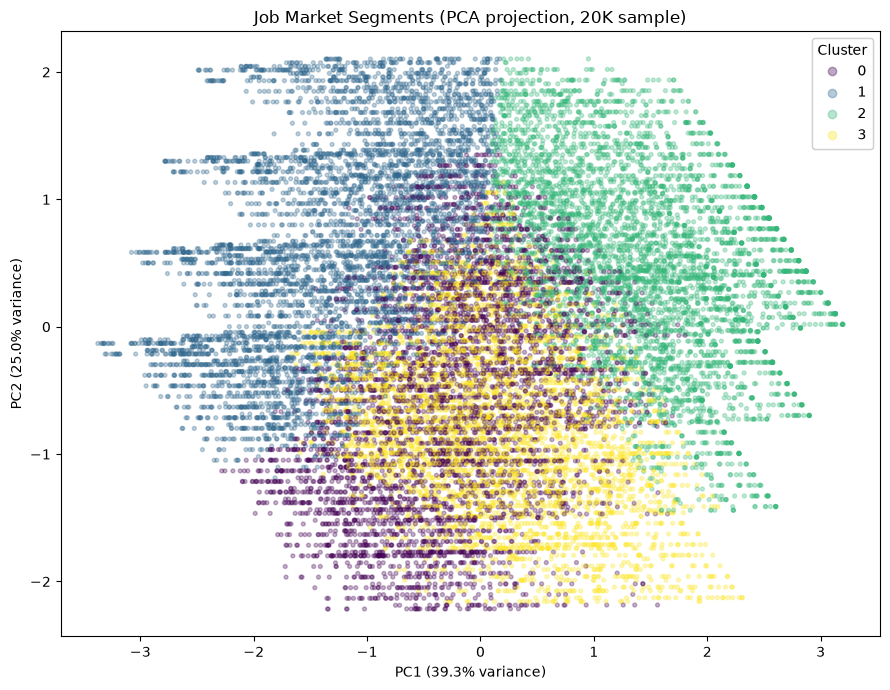

Total Variance Explained by the First Two Principal Components: 64.3%


In [7]:
# Reduce the data to two principal components for visualization.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a random sample for plotting.
sample_plot_idx = np.random.choice(len(X_pca), 20000, replace=False)

# Plot the clusters in the PCA space.
fig, ax = plt.subplots(figsize=(9,7))
scatter = ax.scatter(X_pca[sample_plot_idx,0], X_pca[sample_plot_idx,1],
                      c=df['cluster'].values[sample_plot_idx], cmap='viridis', alpha=0.3, s=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Job Market Segments (PCA projection, 20K sample)')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()

# Save the figure.
fig.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\cluster_pca.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Display the total explained variance.
print(f"Total Variance Explained by the First Two Principal Components: {pca.explained_variance_ratio_.sum():.1%}")


**Interpretation:** The 2D PCA projection captures 64.3% of total variance in just 2 components -- a reasonable, though not overwhelming, summary of the 4-dimensional feature space. Visual inspection of the plot should show the four clusters as overlapping, gradient-like regions rather than tight, isolated blobs -- consistent with the low silhouette scores above. This is expected, not a plotting error.

**Business insight:** The visualization is best used to communicate the *relative positioning* of segments (e.g., which clusters sit closer to "high pay / high credential" vs. "low pay / low tenure") rather than to claim visually crisp, obviously separated groups.

## 7. Save Clustered Dataset

In [8]:
# Save the dataset with the cluster labels.
df.to_parquet(
    r"C:\Users\rashm\Downloads\Job Market\data\processed\job_market_clustered.parquet",
    index=False
)

# Confirm that the dataset was saved successfully.
print("=" * 60)
print("Clustered dataset saved successfully")
print("=" * 60)
print("Location    : C:\\Users\\rashm\\Downloads\\Job Market\\data\\processed\\job_market_clustered.parquet")
print(f"Rows        : {df.shape[0]:,}")
print(f"Columns     : {df.shape[1]}")
print("File Format : Parquet")
print("=" * 60)

Clustered dataset saved successfully
Location    : C:\Users\rashm\Downloads\Job Market\data\processed\job_market_clustered.parquet
Rows        : 499,972
Columns     : 21
File Format : Parquet
